In [1]:
library(edgeR)
library(limma)
library(ggplot2)
library(ggrepel)
library(patchwork)
library(dplyr)
library(scales)
library(EnhancedVolcano)

Loading required package: limma


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




## Load Bulk Count Data

In [2]:
# Retrieve aggregated counts for H1 and H2 as well as gene attributes
tsv_h1   <- "bulk_counts/H1_bulk_counts.tsv"
tsv_h2   <- "bulk_counts/H2_bulk_counts.tsv"

h1 <- read.table(tsv_h1, header = TRUE, sep = "\t", stringsAsFactors = FALSE)
h2 <- read.table(tsv_h2, header = TRUE, sep = "\t", stringsAsFactors = FALSE)

In [3]:
# Merge the two data frames and create a count matrix for downstream analyses
counts_df <- merge(h1, h2, by = c("gene_id", "gene_name"), all = TRUE, suffixes = c("_H1", "_H2"))
counts_df[is.na(counts_df)] <- 0


In [4]:
count_mat <- as.matrix(counts_df[, c("tenx_H1", "tenx_H2", "parse_H1", "parse_H2")])
rownames(count_mat) <- counts_df$gene_id

In [5]:
# Summary
lib_summary <- data.frame(
  Name = colnames(count_mat),
  Sample    = c("H1", "H2", "H1", "H2"),
  Technology = c("10X", "10X", "Parse", "Parse"),
  `Total counts` = colSums(count_mat),
  check.names = FALSE
)

## Load Gene Annotations

In [6]:
gene_attr_path <- "gene_data/gene_attributes.csv"
gene_attrs_raw <- read.csv(gene_attr_path, stringsAsFactors = FALSE)
gene_attrs_raw$X <- NULL

In [54]:
gene_annot <- subset(gene_attrs_raw, gene_id %in% counts_df$gene_id)
bool_cols <- c("is_lnc", "is_pc", "is_mito", "is_ribo")
gene_annot[bool_cols] <- lapply(gene_annot[bool_cols], as.logical)

# Assign a single biotype label (priority: mito_chrom > ribo > pc > lnc > other)
gene_annot$biotype <- "Other"
gene_annot$biotype[gene_annot$is_lnc] <- "lncRNA"
gene_annot$biotype[gene_annot$is_pc] <- "Protein-coding"
gene_annot$biotype[gene_annot$is_ribo] <- "Ribosomal"
gene_annot$biotype[gene_annot$is_mito] <- "Mitochondrial"
gene_annot$biotype <- factor(gene_annot$biotype,
  levels = c("Protein-coding", "lncRNA", "Ribosomal", "Mitochondrial", "Other"))

## edgeR DGEList, filtering, and normalization

In [8]:
tech <- factor(c("tenx", "tenx", "parse", "parse"), levels = c("tenx", "parse"))
sample <- factor(c("H1", "H2", "H1", "H2"), levels = c("H1", "H2"))
design <- model.matrix(~sample + tech)

In [9]:
dge <- DGEList(counts = count_mat, design=design)

# Filter low-count genes using edgeR's standard method
keep <- filterByExpr(dge, design=design)
dge  <- dge[keep, , keep.lib.sizes = FALSE]
# Normalize counts using TMM method
dge <- calcNormFactors(dge, method = "TMM")

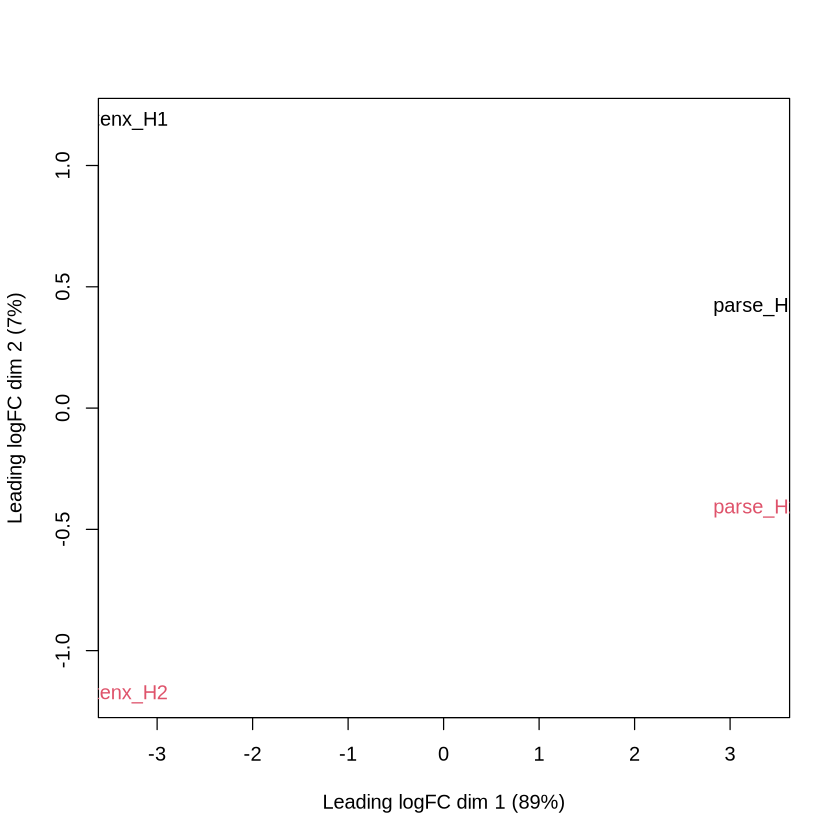

In [10]:
plotMDS(dge, col = as.numeric(sample))

In [11]:
lib_summary$eff_lib = dge$samples$lib.size * dge$samples$norm.factors
lib_summary

,Name,Sample,Technology,Total counts,eff_lib
,<chr>,<chr>,<chr>,<dbl>,<dbl>
tenx_H1,tenx_H1,H1,10X,31625875,26932228
tenx_H2,tenx_H2,H2,10X,33067730,28651518
parse_H1,parse_H1,H1,Parse,37954846,43291436
parse_H2,parse_H2,H2,Parse,34573027,40871110


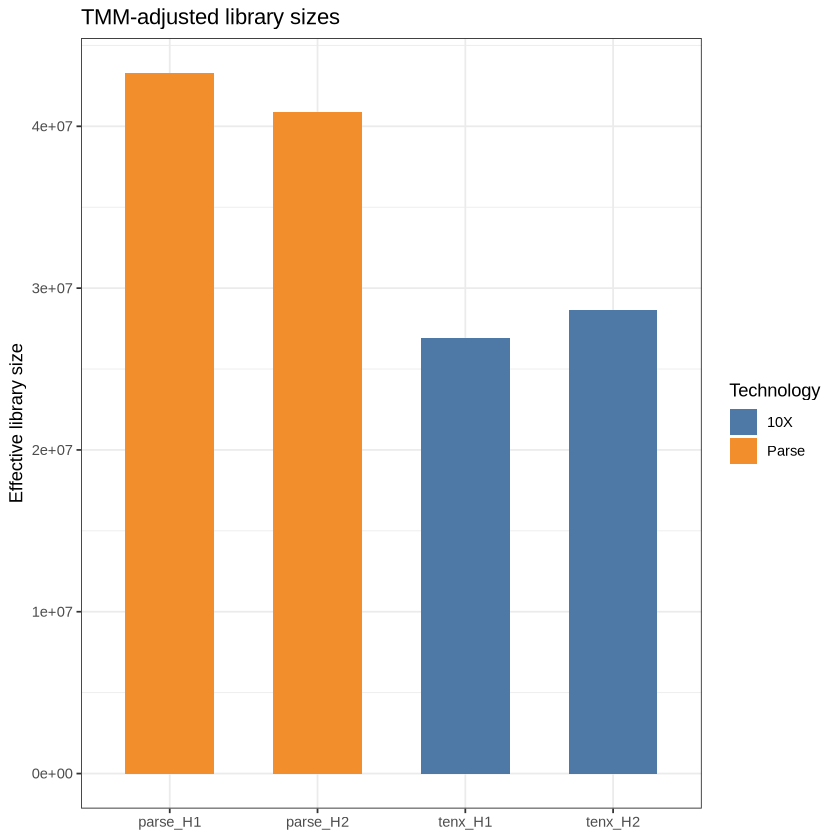

In [12]:
lib_summary$eff_lib = dge$samples$lib.size * dge$samples$norm.factors


ggplot(lib_summary, aes(x = Name, y = eff_lib, fill = Technology)) +
  geom_col(width = 0.6) +
  scale_fill_manual(values = c("10X" = "#4e79a7", "Parse" = "#f28e2b")) +
  labs(x = NULL, y = "Effective library size", fill = "Technology",
       title = "TMM-adjusted library sizes") +
  theme_bw()

## Fit to Data

In [37]:
dge <- estimateDisp(dge, design)
fit <- glmQLFit(dge, design)

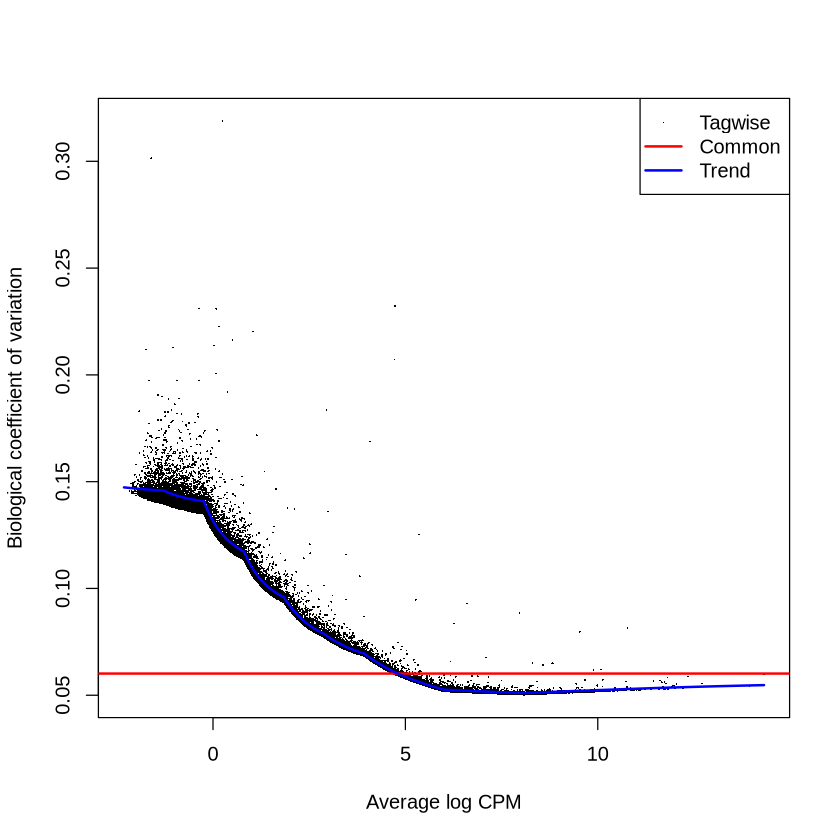

In [38]:
plotBCV(dge)

## Perform DE Analysis

In [39]:
qlf <- glmQLFTest(fit, coef = "techparse")

results <- topTags(qlf, n = Inf, sort.by = "PValue")$table
results$gene_id <- rownames(results)

# Merge with annotations (keep all DE results; annotation may be NA)
results <- merge(results, gene_annot, by = "gene_id", all.x = TRUE)
results$biotype[is.na(results$biotype)] <- "Other"

sig_up   <- sum(results$FDR < 0.05 & results$logFC > 0, na.rm = TRUE)
sig_down <- sum(results$FDR < 0.05 & results$logFC < 0, na.rm = TRUE)
cat("Genes tested:", nrow(results), "\n")
cat("FDR < 0.05, higher in Parse:", sig_up, "\n")
cat("FDR < 0.05, higher in 10X:  ", sig_down, "\n")

Genes tested: 22208 
FDR < 0.05, higher in Parse: 9471 
FDR < 0.05, higher in 10X:   7753 


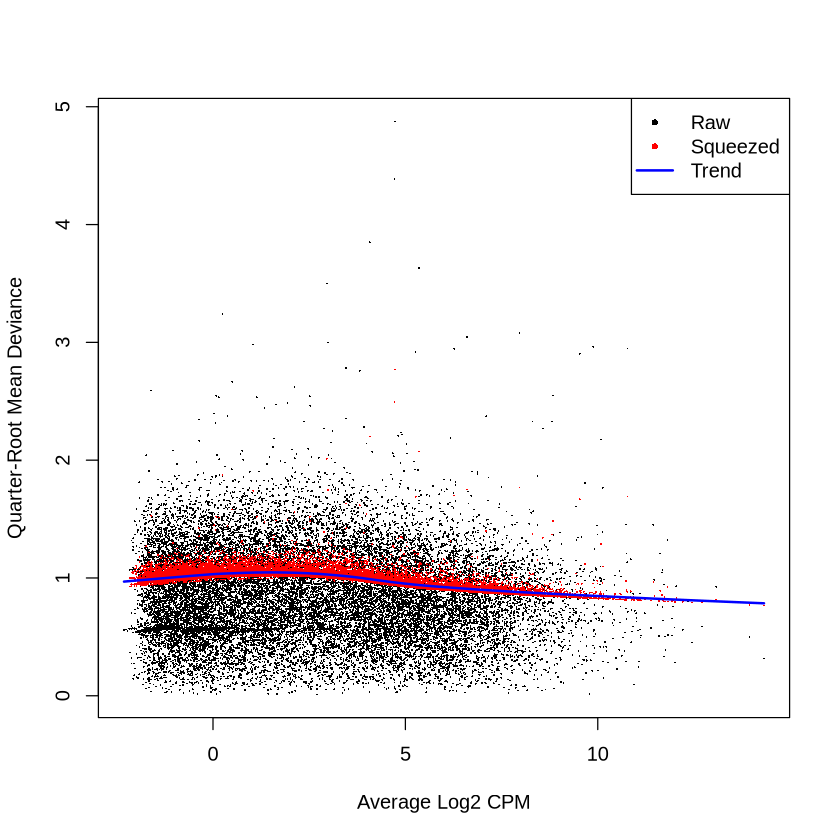

In [40]:
plotQLDisp(fit)

In [41]:
top20 <- results[order(results$FDR), ][1:20, c("gene_name", "logFC", "logCPM", "F", "PValue", "FDR")]
top20[, c("logFC", "logCPM", "F")] <- round(top20[, c("logFC", "logCPM", "F")], 3)
top20$PValue <- signif(top20$PValue, 3)
top20$FDR    <- signif(top20$FDR, 3)

In [42]:
sig_colors <- c("Higher in Parse" = "#f28e2b", "Higher in 10X" = "#4e79a7", "n.s." = "grey70")

results$direction <- "n.s."
results$direction[results$FDR < 0.05 & results$logFC > 0] <- "Higher in Parse"
results$direction[results$FDR < 0.05 & results$logFC < 0] <- "Higher in 10X"
results$direction <- factor(results$direction, levels = names(sig_colors))

# Top genes to label
top_label <- results[order(results$FDR), ][1:15, ]

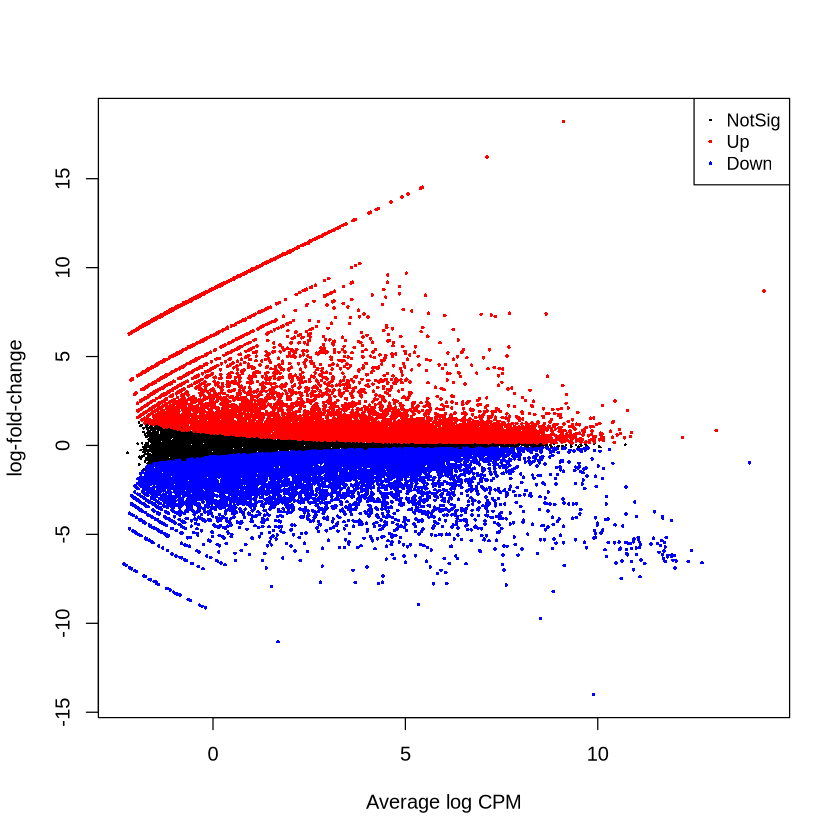

In [43]:
# Identify differentially expressed genes at FDR < 0.05
is.de <- decideTests(qlf)
# Generate the MD plot with DE genes highlighted
plotMD(qlf, status = is.de, col = c("red","blue"), main="", cex=0.4)

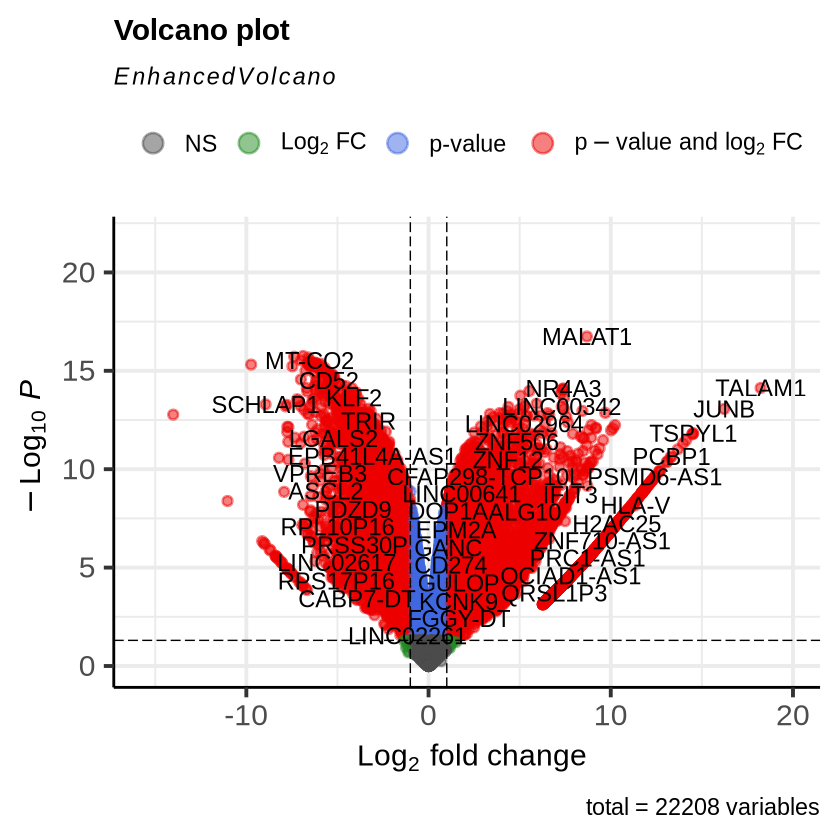

In [44]:
# Rank genes by p-value and log fold change for volcano plot
res <- topTags(qlf, n=Inf)$table 
res$gene_name <- gene_annot$gene_name[match(rownames(res), gene_annot$gene_id)]

# Create volcano plot using EnhancedVolcano
EnhancedVolcano(
    res,
    lab = res$gene_name,
    x = 'logFC',
    y = 'PValue',
    pCutoff = 0.05,
    FCcutoff = 1.0)

`geom_smooth()` using formula = 'y ~ x'


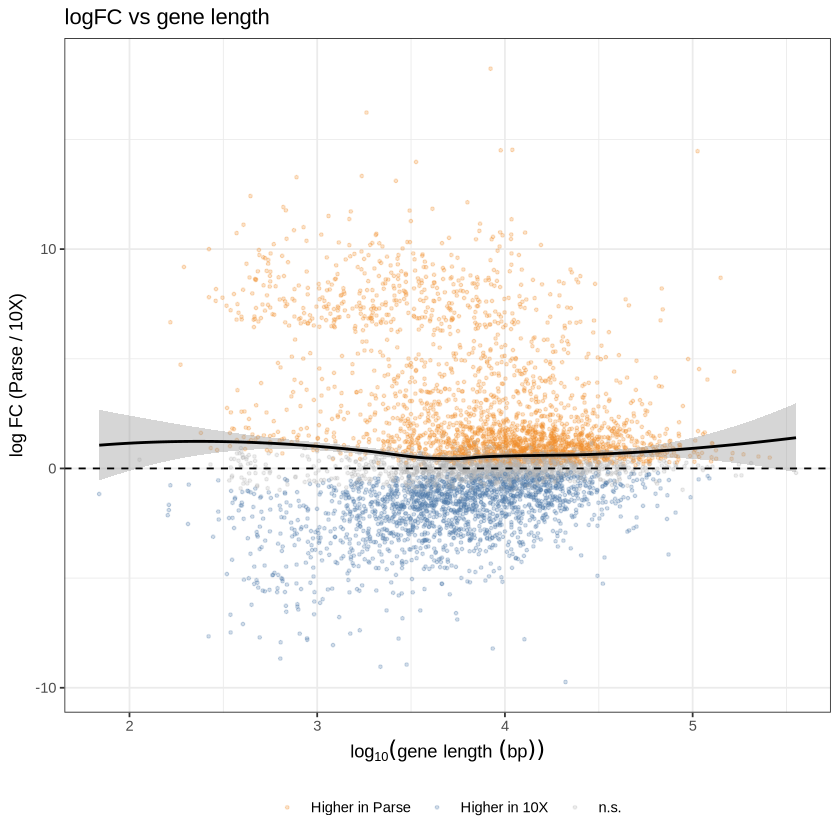

In [45]:
ann_results <- results[!is.na(results$gene_length), ]

ggplot(ann_results, aes(x = log10(gene_length), y = logFC, color = direction)) +
  geom_point(alpha = 0.25, size = 0.7) +
  geom_smooth(aes(group = 1), method = "loess", color = "black", linewidth = 0.8, se = TRUE) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  scale_color_manual(values = sig_colors) +
  labs(x = expression(log[10](gene~length~(bp))), y = "log FC (Parse / 10X)",
       color = NULL, title = "logFC vs gene length") +
  theme_bw() +
  theme(legend.position = "bottom")

`geom_smooth()` using formula = 'y ~ x'


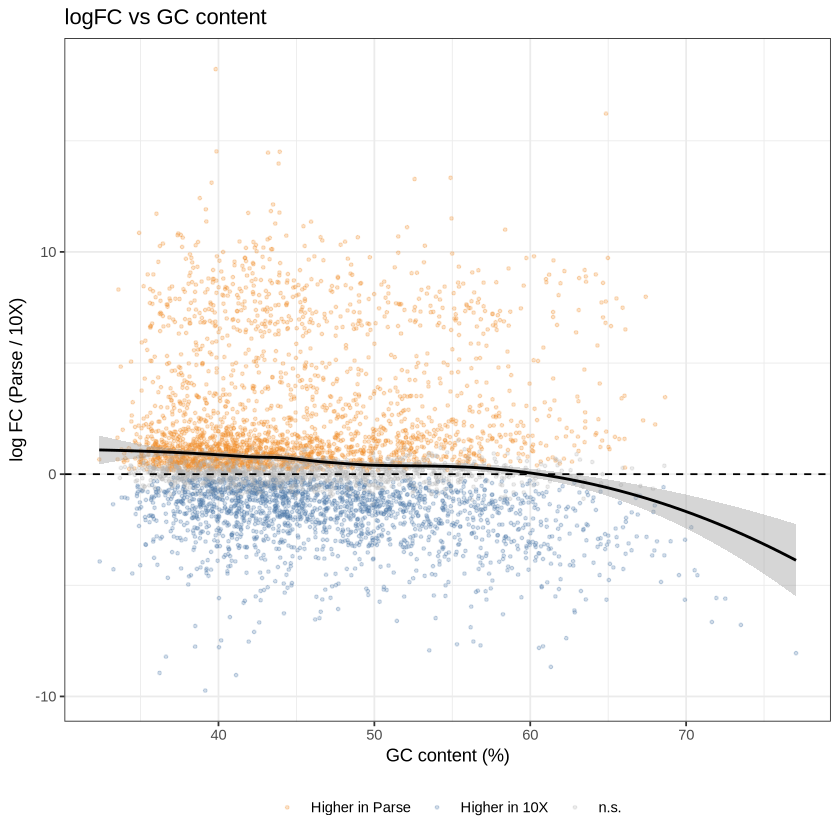

In [46]:
ann_results_gc <- results[!is.na(results$gc_content), ]

ggplot(ann_results_gc, aes(x = gc_content, y = logFC, color = direction)) +
  geom_point(alpha = 0.25, size = 0.7) +
  geom_smooth(aes(group = 1), method = "loess", color = "black", linewidth = 0.8, se = TRUE) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  scale_color_manual(values = sig_colors) +
  labs(x = "GC content (%)", y = "log FC (Parse / 10X)",
       color = NULL, title = "logFC vs GC content") +
  theme_bw() +
  theme(legend.position = "bottom")

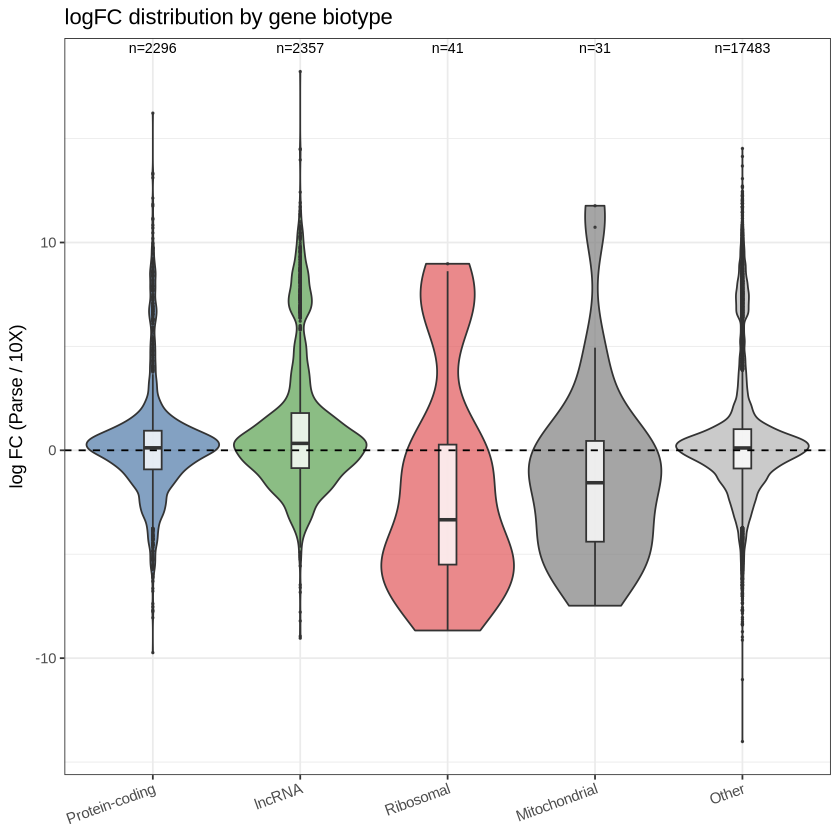

In [47]:
biotype_n <- results %>%
  group_by(biotype) %>%
  summarise(n = n(), median_fc = median(logFC, na.rm = TRUE), .groups = "drop")

biotype_colors <- c(
  "Protein-coding"      = "#4e79a7",
  "lncRNA"              = "#59a14f",
  "Ribosomal"           = "#e15759",
  "Mitochondrial (MT-)" = "#b07aa1",
  "Other"               = "grey70"
)

ggplot(results, aes(x = biotype, y = logFC, fill = biotype)) +
  geom_violin(trim = TRUE, scale = "width", alpha = 0.7) +
  geom_boxplot(width = 0.12, outlier.size = 0.3, fill = "white", alpha = 0.8) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  geom_text(
    data = biotype_n, aes(x = biotype, y = Inf, label = paste0("n=", n)),
    vjust = 1.5, size = 3, inherit.aes = FALSE
  ) +
  scale_fill_manual(values = biotype_colors) +
  labs(x = NULL, y = "log FC (Parse / 10X)",
       title = "logFC distribution by gene biotype") +
  theme_bw() +
  theme(legend.position = "none", axis.text.x = element_text(angle = 20, hjust = 1))

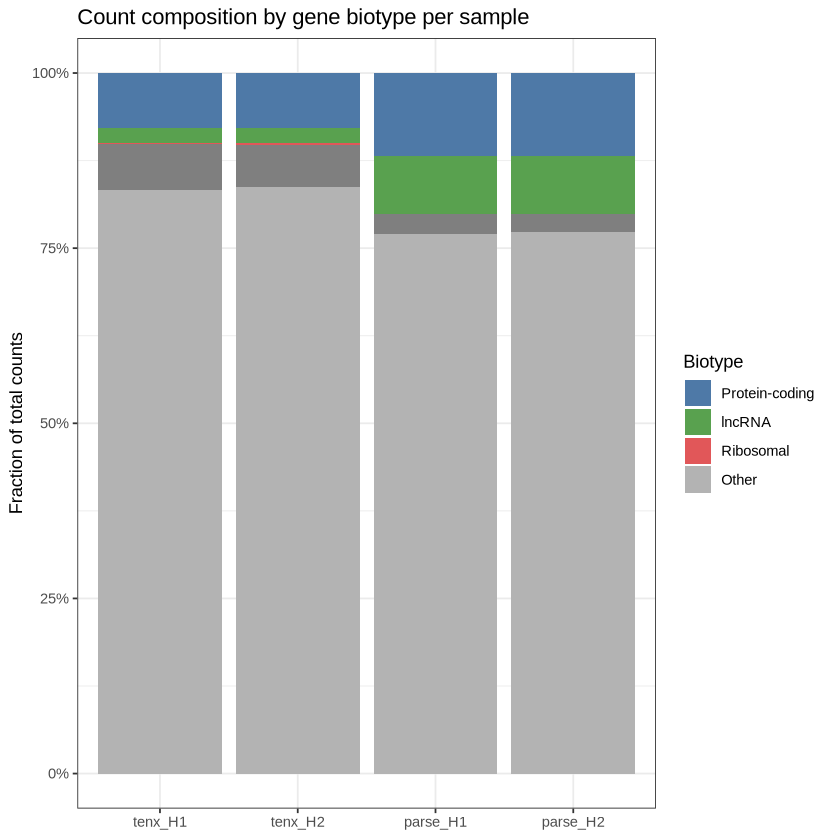

In [48]:
# Subset count_mat to genes that passed filterByExpr and have biotype annotation
kept_genes <- rownames(dge)
comp_df <- results[results$gene_id %in% kept_genes, c("gene_id", "biotype")]
comp_mat <- count_mat[comp_df$gene_id, ]

comp_long <- data.frame(
  sample  = rep(colnames(comp_mat), each = nrow(comp_mat)),
  tech    = rep(c("10X", "10X", "Parse", "Parse"), each = nrow(comp_mat)),
  count   = as.vector(comp_mat),
  biotype = rep(comp_df$biotype, times = ncol(comp_mat))
)

comp_summary <- comp_long %>%
  group_by(sample, tech, biotype) %>%
  summarise(total = sum(count), .groups = "drop") %>%
  group_by(sample) %>%
  mutate(fraction = total / sum(total)) %>%
  ungroup()

comp_summary$sample <- factor(comp_summary$sample,
  levels = c("tenx_H1", "tenx_H2", "parse_H1", "parse_H2"))

ggplot(comp_summary, aes(x = sample, y = fraction, fill = biotype)) +
  geom_col(position = "stack") +
  scale_fill_manual(values = biotype_colors) +
  scale_y_continuous(labels = percent_format()) +
  labs(x = NULL, y = "Fraction of total counts", fill = "Biotype",
       title = "Count composition by gene biotype per sample") +
  theme_bw()